## Import lib and data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_name = "../data/fic_etiq_edition_40-mars-2015.zip"
data = pd.read_csv(data_name, encoding = "ISO-8859-1",sep=';')

data

,lib_mrq_doss,lib_mod_doss,mrq_utac,mod_utac,dscom,cnit,tvv,energ,hybride,puiss_admin,...,co2_mixte,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj
0,ALFA ROMEO,159,ALFA ROMEO,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,...,182.0,0.647,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-14
1,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,...,136.0,0.192,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-14
2,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,...,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-14
3,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,...,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-14
4,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,...,139.0,0.060,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20875,VOLVO,XC90,VOLVO,XC90,XC90 T6 AWD Geartronic 8 7PL 2400kg,M1GVLVVPB92R061,LFA2FC,ES,non,21,...,186.0,0.224,0.048,0.021,NaN,0.002,2033,2033,715/2007*136/2014EURO6,mars-15
20876,VOLVO,XC90,VOLVO,XC90,XC90 D5 AWD Geartronic 8 7PL 2400kg,M1GVLVVPB92S062,LFA47C,GO,non,13,...,149.0,0.308,NaN,0.076,0.119,0.001,2038,2038,715/2007*136/2014EURO6,mars-15
20877,VOLVO,XC90,VOLVO,XC90,XC90 D5 AWD Geartronic 8 7PL 2700kg,M1GVLVVPB92T063,LFA48C,GO,non,13,...,149.0,0.308,NaN,0.076,0.119,0.001,2038,2038,715/2007*136/2014EURO6,mars-15
20878,VOLVO,XC90,VOLVO,XC90,"XC90 D5 AWD Geartronic 8 7PL 2700kg jantes 18""...",M1GVLVVPB92U064,LFA4BC,GO,non,13,...,152.0,0.302,NaN,0.075,0.119,0.001,2038,2038,715/2007*136/2014EURO6,mars-15


## Exploration

In [28]:
def simplifier_energie(label):
    label = str(label).upper()
    if 'ESSENCE' in label or 'EE' in label or 'ES' in label :
        return 'Unlead pertrol'
    elif 'GASOIL' in label or 'GO' in label:
        return 'Diesel'
    elif 'EH' in label or 'GH' in label:
        return 'Hybrid'
    elif 'EL' in label or 'ELECTRIQUE' in label:
        return 'Électrique'
    else:
        return 'Autre'

# Application de la simplification
data['energie_groupee'] = data['energ'].apply(simplifier_energie)

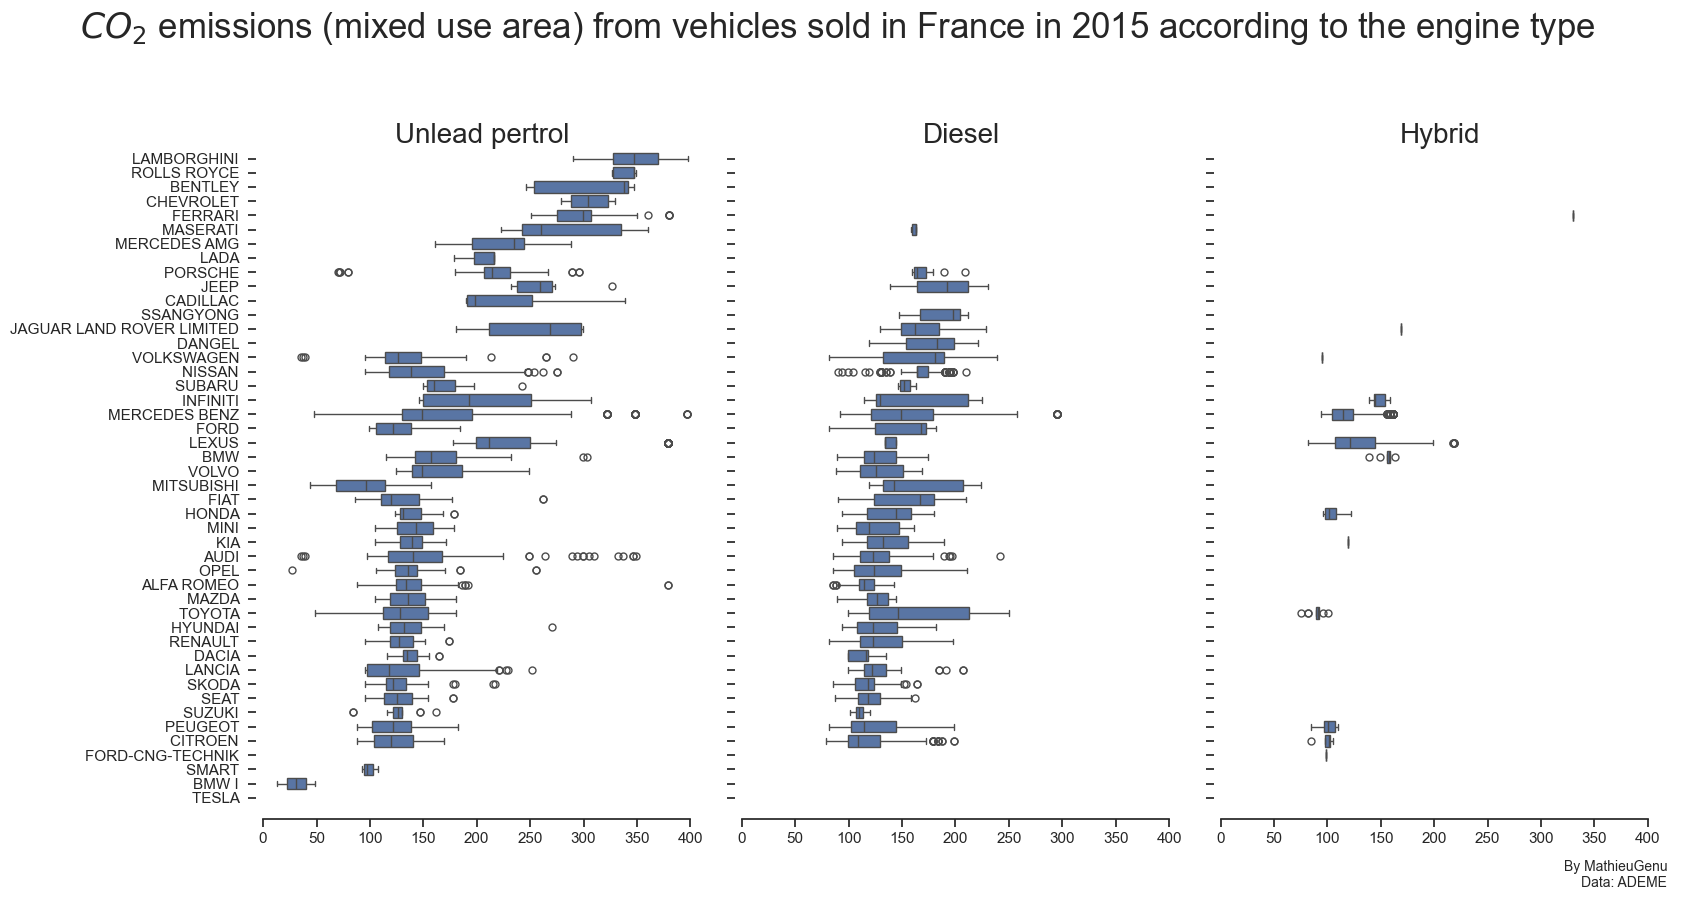

In [33]:
brand_order = (
    data.groupby("lib_mrq_doss")["co2_mixte"]
    .median()
    .sort_values(ascending=False)
    .index
)

df_plot = data[
    (data["energie_groupee"] != "Autre") & (data["energie_groupee"] != "Électrique")
]
sns.set_theme(style="ticks")

g = sns.catplot(
    data=df_plot,
    y="lib_mrq_doss",
    x="co2_mixte",
    col="energie_groupee",  # Utilisation de la nouvelle colonne
    kind="box",
    order=brand_order,
    height=8,
    aspect=0.7,
    # col_wrap=3,
    sharey=True,
)
g.set_titles("{col_name}", size = 20)
g.set(xlabel=None, ylabel=None)
plt.suptitle(
    "$CO_2$ emissions (mixed use area) from vehicles sold in France in 2015 according to the engine type",
    fontsize=25,
    y = 1.05
)
g.fig.text(
    0.99, -0.05, 
    "By MathieuGenu\nData: ADEME", 
    fontsize=10, 
    # color="gray", 
    ha="right", 
    va="bottom"
)
# g.fig.subplots_adjust(bottom=0.15, top=0.90)

plt.tight_layout()
sns.despine(offset=10, 
            left=True,
            trim=True,
            )

plt.savefig("../graph/cars_co2_emission.png", bbox_inches='tight',facecolor="white")